# Atividade PBL - Diagnostico de Imagens

**Disciplina:** Processamento de Imagens
**Turma:** CC8MA
**Prof.:** Claudio M. S. Coutinho

**Integrantes:**
- JOAO BAGANHA 1
- JOAO BAGANHA 2
- JOAO BAGANHA 3

## Situacao

Recebemos 5 imagens com problemas distintos de visualizacao. Para cada uma, o objetivo e: gerar o histograma, diagnosticar o problema, escolher e aplicar a tecnica adequada e comparar o resultado (imagem + histograma) antes e depois do processamento.

Ao longo dos 5 casos sao usadas todas as tecnicas pedidas: **negativo digital, limiarizacao, expansao de contraste, equalizacao de histograma e correcao Gamma**.

In [12]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Carregando as imagens

As imagens estao salvas localmente na pasta `instrucoes_pbl/imagens/`, entao carregamos direto pelo caminho do arquivo (sem upload).

In [14]:
caminho_imagens = 'instrucoes_pbl/imagens/'

imagem_01_bgr = cv2.imread(caminho_imagens + 'imagem_01.png')
imagem_02_bgr = cv2.imread(caminho_imagens + 'imagem_02.png')
imagem_03_bgr = cv2.imread(caminho_imagens + 'imagem_03.png')
imagem_04_bgr = cv2.imread(caminho_imagens + 'imagem_04.png')
imagem_05_bgr = cv2.imread(caminho_imagens + 'imagem_05.png')

imagem_01_gray = cv2.cvtColor(imagem_01_bgr, cv2.COLOR_BGR2GRAY)
imagem_02_gray = cv2.cvtColor(imagem_02_bgr, cv2.COLOR_BGR2GRAY)
imagem_03_gray = cv2.cvtColor(imagem_03_bgr, cv2.COLOR_BGR2GRAY)
imagem_04_gray = cv2.cvtColor(imagem_04_bgr, cv2.COLOR_BGR2GRAY)
imagem_05_gray = cv2.cvtColor(imagem_05_bgr, cv2.COLOR_BGR2GRAY)

## Funcao para calcular o histograma

Mesma funcao `calcularHist()` usada nos notebooks de aula.

In [15]:
def calcularHist(img):
  imgVetor = img.ravel()
  histVetor = np.zeros(256, dtype = np.int64)
  for px in imgVetor:
    histVetor[px] += 1

  return histVetor

## Funcao auxiliar de diagnostico

Monta o subplot 2x2 pedido na atividade: imagem original, histograma original, imagem resultado e histograma final.

In [16]:
def plot_diagnostico(original, resultado, titulo):
    hist_original = calcularHist(original)
    hist_resultado = calcularHist(resultado)

    fig, eixos = plt.subplots(2, 2, figsize=(12, 9))

    eixos[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    eixos[0, 0].set_title(f'{titulo} - Original')
    eixos[0, 0].axis('off')

    eixos[0, 1].bar(range(256), hist_original)
    eixos[0, 1].set_title('Histograma Original')

    eixos[1, 0].imshow(resultado, cmap='gray', vmin=0, vmax=255)
    eixos[1, 0].set_title(f'{titulo} - Resultado')
    eixos[1, 0].axis('off')

    eixos[1, 1].bar(range(256), hist_resultado)
    eixos[1, 1].set_title('Histograma Resultado')

    plt.tight_layout()
    plt.show()

## Caso 1 - Imagem 01 (estacionamento)

**Diagnostico:** o histograma mostra os pixels quase todos concentrados entre 0 e 22 (media ~ 7, desvio padrao ~ 7,7). A imagem esta fortemente subexposta: praticamente nao ha informacao em tons medios e claros, dificultando enxergar os carros, os pilares e a pessoa ao fundo do corredor.

**Tecnica/parametros:** correcao Gamma com gamma = 0.4, aplicada via LUT (`cv2.LUT`). Como gamma < 1, os tons escuros sao expandidos de forma nao linear, clareando as sombras sem estourar os poucos pixels ja claros (como a luz do teto).

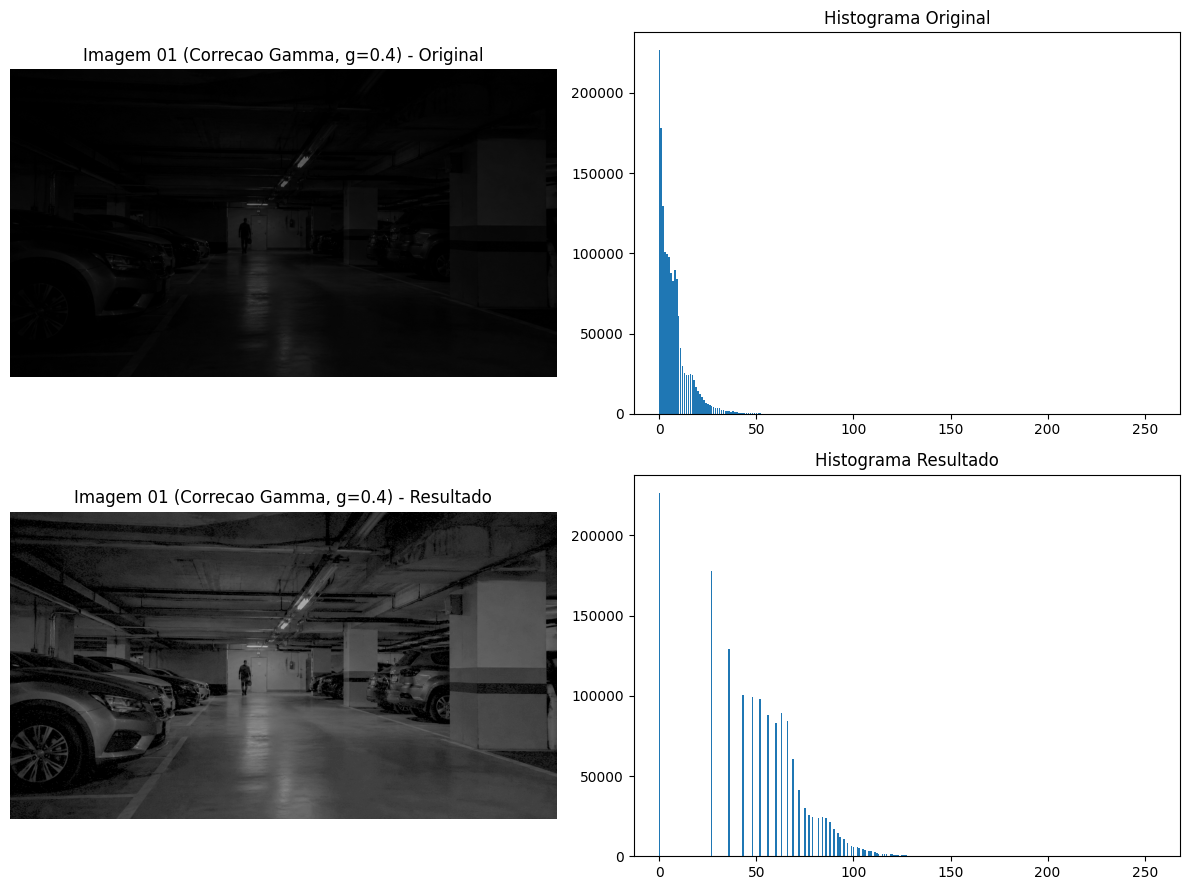

In [17]:
gamma_imagem_01 = 0.4
tabela_gamma_01 = np.array([((i / 255.0) ** gamma_imagem_01) * 255 for i in range(256)]).astype('uint8')
imagem_01_resultado = cv2.LUT(imagem_01_gray, tabela_gamma_01)

plot_diagnostico(imagem_01_gray, imagem_01_resultado, 'Imagem 01 (Correcao Gamma, g=0.4)')

**Justificativa:** a correcao Gamma permite controlar, via parametro gamma, a intensidade do realce dos tons escuros sem saturar as areas ja iluminadas. Depois do ajuste o histograma passa a ocupar toda a faixa de 0 a 255 e a cena da garagem fica visivel.

## Caso 2 - Imagem 02 (bancada de laboratorio)

**Diagnostico:** o histograma e estreito, concentrado entre 70 e 143 (desvio padrao ~ 10,2). Isso indica baixo contraste: a imagem parece "lavada", como se houvesse um veu acinzentado cobrindo a bancada e os objetos de laboratorio.

**Tecnica/parametros:** expansao de contraste (contrast stretching), mapeando linearmente o intervalo [minimo, maximo] da imagem para [0, 255].

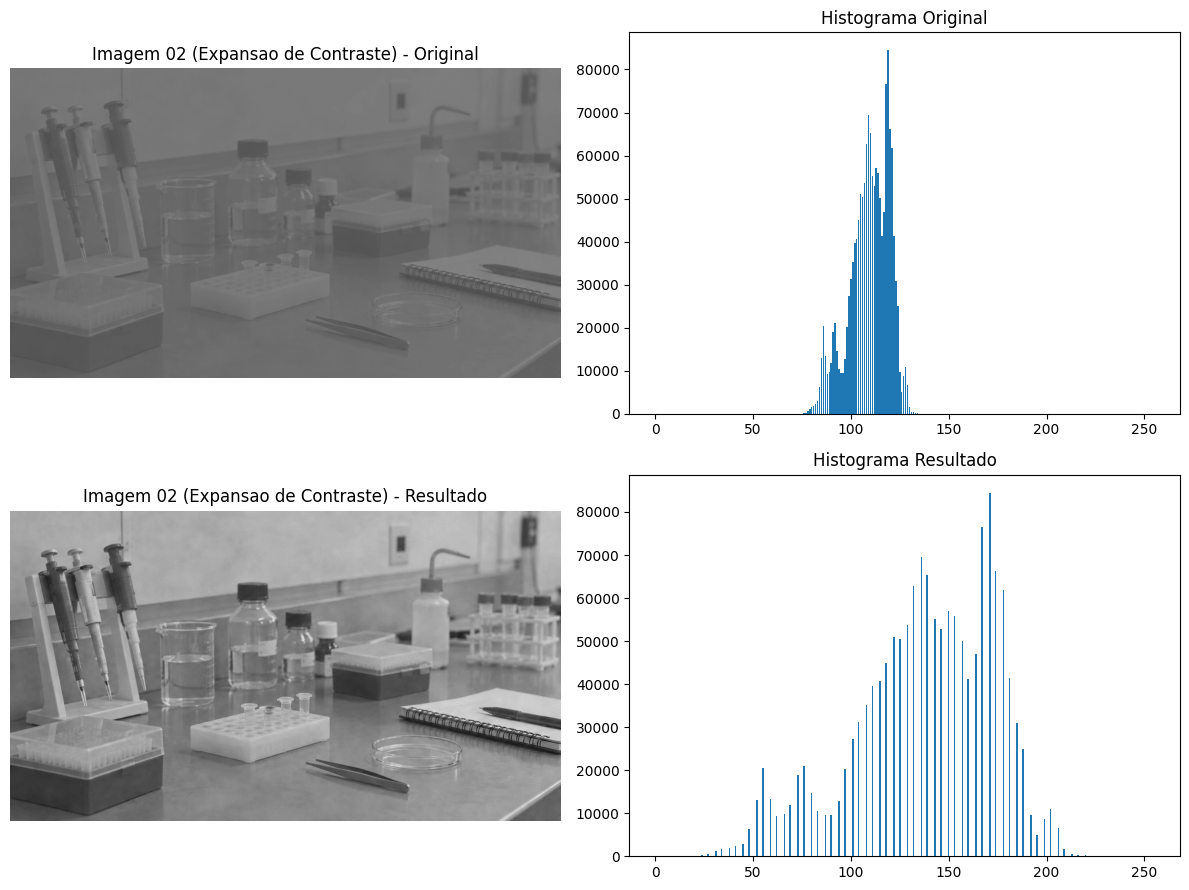

In [18]:
min_val_02 = imagem_02_gray.min()
max_val_02 = imagem_02_gray.max()

imagem_02_resultado = (imagem_02_gray.astype(np.float32) - min_val_02) * (255.0 / (max_val_02 - min_val_02))
imagem_02_resultado = imagem_02_resultado.clip(0, 255).astype(np.uint8)

plot_diagnostico(imagem_02_gray, imagem_02_resultado, 'Imagem 02 (Expansao de Contraste)')

**Justificativa:** como o problema e a faixa dinamica estreita (poucos tons ocupando quase todo o intervalo possivel), o esticamento linear ja e suficiente para redistribuir os valores existentes por toda a escala, sem alterar a proporcao entre eles. O resultado tem contraste bem mais nitido entre os instrumentos e a bancada.

## Caso 3 - Imagem 03 (rua com neblina)

**Diagnostico:** a cena de rua aparece "enevoada". O desvio padrao e moderado (~ 23,3), mas grande parte dos pixels esta concentrada em tons medios (62 a 150), comprimindo os detalhes de sombra e de luz da rua e dos predios.

**Tecnica/parametros:** equalizacao de histograma, usando `cv2.equalizeHist()`.

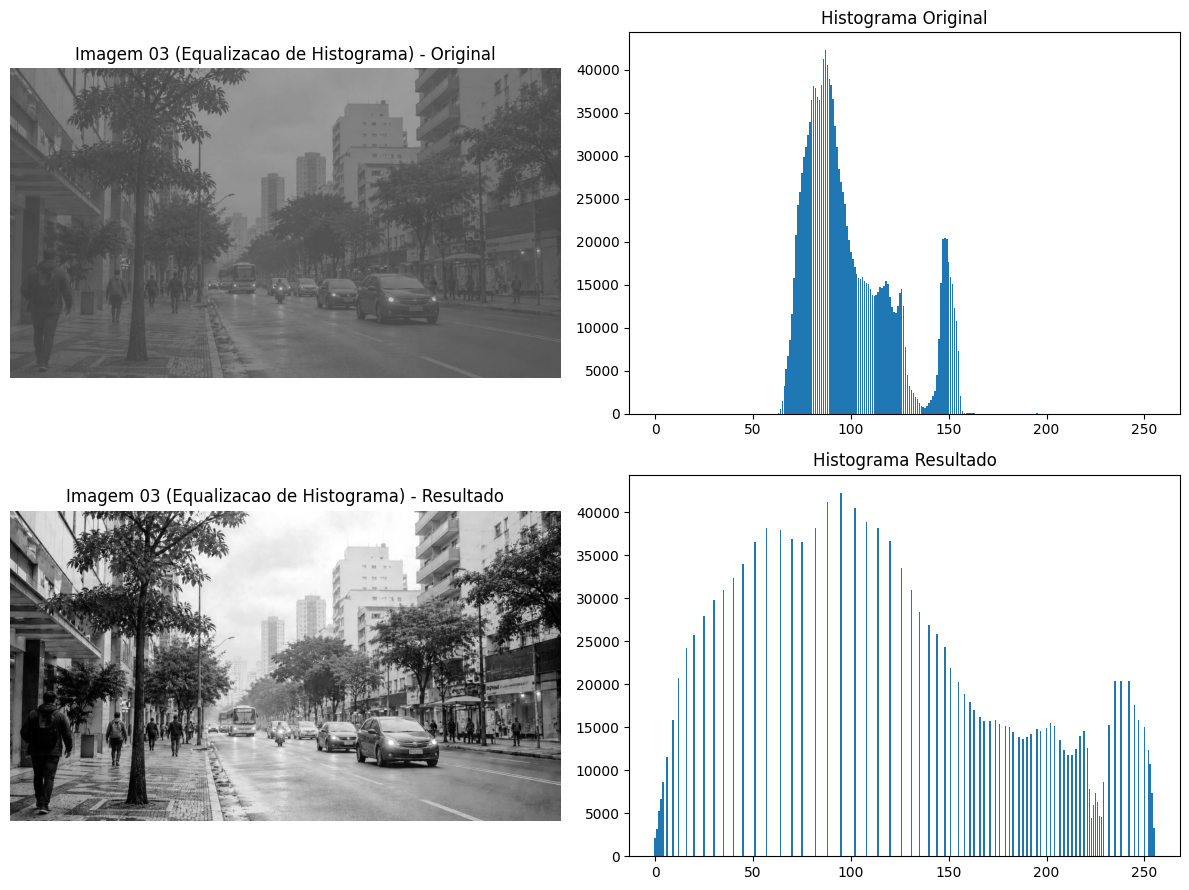

In [19]:
imagem_03_resultado = cv2.equalizeHist(imagem_03_gray)

plot_diagnostico(imagem_03_gray, imagem_03_resultado, 'Imagem 03 (Equalizacao de Histograma)')

**Justificativa:** diferente da Imagem 02, aqui os tons ja ocupam uma faixa razoavel, porem estao mal distribuidos (concentracao excessiva em tons medios). A equalizacao redistribui as intensidades pela frequencia acumulada, realcando o contraste global e revelando detalhes da rua, dos veiculos e das pessoas que estavam encobertos pela neblina.

## Caso 4 - Imagem 04 (pecas na esteira)

**Diagnostico:** a imagem tem boa faixa dinamica (desvio padrao ~ 43,7) e histograma bimodal: um pico forte em tons escuros (20-45, a esteira) e uma distribuicao mais espalhada em tons medios/claros (as pecas metalicas). Aqui o problema nao e exposicao, e sim separar os objetos do fundo para inspecao/contagem automatica.

**Tecnica/parametros:** limiarizacao binaria pelo metodo de Otsu (`cv2.THRESH_BINARY + cv2.THRESH_OTSU`), que encontra automaticamente o limiar que melhor separa os dois picos do histograma.

Limiar calculado (Otsu): 89.0


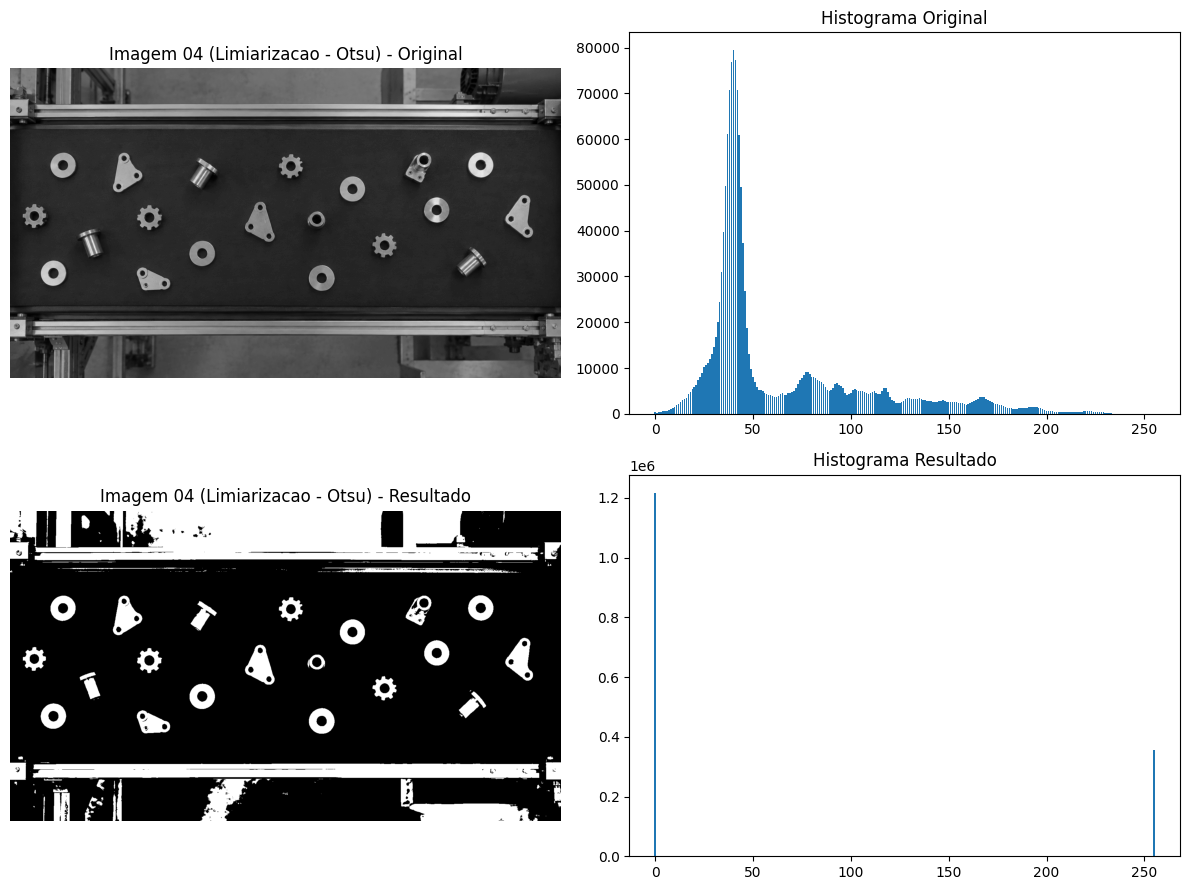

In [20]:
limiar_04, imagem_04_resultado = cv2.threshold(imagem_04_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('Limiar calculado (Otsu):', limiar_04)

plot_diagnostico(imagem_04_gray, imagem_04_resultado, 'Imagem 04 (Limiarizacao - Otsu)')

**Justificativa:** como o histograma e claramente bimodal (fundo escuro x pecas metalicas mais claras), a limiarizacao e a tecnica adequada para segmentar a imagem, e o metodo de Otsu evita escolher o limiar manualmente. O resultado e uma mascara binaria que isola as pecas da esteira, util para contagem ou inspecao automatica.

## Caso 5 - Imagem 05 (desenho tecnico)

**Diagnostico:** o desenho tecnico esta com a polaridade invertida: linhas e anotacoes claras sobre um fundo quase preto (media ~ 44,6). Esse formato dificulta a leitura e a impressao do desenho, que normalmente e apresentado com fundo branco e tracos escuros.

**Tecnica/parametros:** negativo digital, ou seja, `resultado = 255 - imagem`.

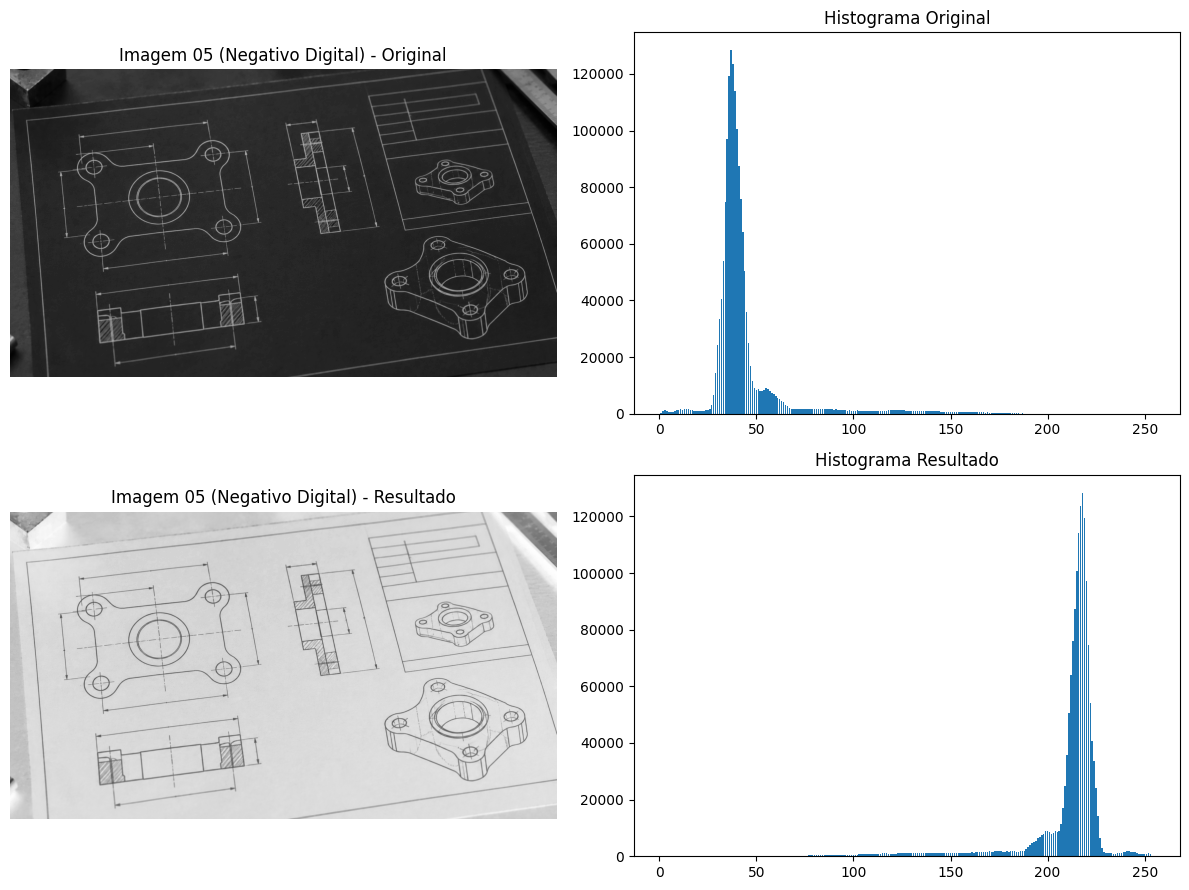

In [21]:
imagem_05_resultado = 255 - imagem_05_gray

plot_diagnostico(imagem_05_gray, imagem_05_resultado, 'Imagem 05 (Negativo Digital)')

**Justificativa:** o negativo digital inverte diretamente a polaridade dos tons (px -> 255 - px), sem alterar o contraste relativo entre eles. Isso ja e suficiente para transformar o desenho tecnico no padrao convencional (fundo claro, tracos escuros), facilitando a leitura das cotas e das vistas do projeto.

## Conclusao

Cada uma das 5 imagens apresentava um problema diferente de visualizacao, identificado a partir do formato do seu histograma (concentracao em tons escuros, faixa dinamica estreita, tons medios comprimidos, distribuicao bimodal e polaridade invertida). Ao longo do conjunto foram aplicadas as 5 tecnicas pedidas - correcao Gamma, expansao de contraste, equalizacao de histograma, limiarizacao e negativo digital - cada uma escolhida por ser a mais adequada ao diagnostico especifico de cada imagem.